# Lab: 2D Convolution with Numba CUDA

---
Your information:
- Student Name: Phùng Quốc Tuấn
- Student ID: 19127616

---
## Objectives

By the end of this lab you will be able to:

1. Write 2D CUDA kernels in Python using `@cuda.jit`
2. Compute 2D thread and block indices correctly
3. Handle boundary conditions at image edges
4. Implement shared memory tiling with halo regions
5. Reuse the same kernel infrastructure for multiple filter types
6. Measure arithmetic intensity and reason about memory-bound vs compute-bound kernels
7. Use constant memory for read-only broadcast data
8. Apply thread coarsening to increase arithmetic intensity

---
## Instructions

### How to Complete This Lab

**Important:** This notebook will be graded using automated testing. Please follow the instructions carefully.

**Completing the Tasks**

1. Fill in your name and student ID at the top of this notebook.

2. Complete the code in cells marked with:
```python
# YOUR CODE HERE
raise NotImplementedError()
```

3. Delete the `raise NotImplementedError()` line when you implement your solution.

4. For optional tasks:
```python
# YOUR CODE HERE (OPTIONAL)
```

5. For written answers:
```markdown
YOUR ANSWER HERE
```

**Testing Your Code**

- Below each task, there are test cells to verify your implementation.
- If a test cell runs without errors, your code passes that test.
- Passing all visible tests does not guarantee full correctness - there may be hidden test cases.

**Before Submission**

1. Run `Kernel` → `Restart Kernel & Run All Cells` to ensure everything works.
2. Remove any debug print statements or extra cells you created.
3. **Do not modify** the provided code cells or test cells.

**Submission Format**

```
StudentID/
└── HW02.ipynb
```

Compress the `StudentID` folder by uisng **zip**, named as **StudentID.zip** and submit.

**Academic Integrity**
- The goal is to **learn authentically**. You may discuss ideas with classmates, but your code and answers must be your own work based on your genuine understanding.
- **Plagiarism or cheating will result in a score of 0 for the entire course.**

---

## Connection to Your Final Project

2D convolution is the foundational operation in nearly every GPU-accelerated image or signal processing pipeline:

| Final project topic | How this lab prepares it |
|---|---|
| U-Net / CNN inference | Conv layers are exactly this operation |
| Image processing pipelines | Blur, edge detection are standard preprocessing |
| N-body / stencil solvers | Halo exchange follows the same tiling pattern |
| Any batched tensor op | 2D thread indexing generalizes directly |

---

## The Problem: 2D Image Convolution

Given a grayscale image of shape `(H, W)` and a small filter kernel of shape `(K, K)`, compute the output image where each pixel is the weighted sum of its `K x K` neighborhood:

```
output[r, c] = sum over (i, j) of: image[r+i-K//2, c+j-K//2] * kernel[i, j]
```

Pixels outside the image boundary are treated as zero (zero-padding).

---

## Setup

In [1]:
# !pip install numba  # uncomment if needed

import numpy as np
import numba
from numba import cuda
import math
import time
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
print(f"NumPy  version : {np.__version__}")
print(f"Numba  version : {__import__('numba').__version__}")
print(f"CUDA available : {cuda.is_available()}")
if cuda.is_available():
    gpu = cuda.get_current_device()
    gpu_name = gpu.name.decode() if isinstance(gpu.name, bytes) else gpu.name
    print(f"GPU            : {gpu_name}")
    print(f"Compute cap.   : {gpu.compute_capability}")
    cc = gpu.compute_capability
    print(f"Max shared mem : {gpu.MAX_SHARED_MEMORY_PER_BLOCK / 1024:.0f} KB per block")

NumPy  version : 2.0.2
Numba  version : 0.60.0
CUDA available : True
GPU            : Tesla T4
Compute cap.   : ComputeCapability(major=7, minor=5)
Max shared mem : 48 KB per block


In [3]:
# Image and filter configuration
H, W   = 1024, 1024   # image size
K      = 15           # filter size (K x K), must be odd
                      # K=15 chosen deliberately: large enough for shared memory
                      # tiling to show real speedup over naive (64x more AI),
                      # while still fitting in 48 KB shared memory (3.5 KB used).
HALF_K = K // 2       # = 7
TILE   = 16           # tile size (threads per block dim)
SHARED_DIM = TILE + 2 * HALF_K   # = 30  (used in roofline analysis)

In [4]:
# --- Filters ---

# Large Gaussian blur 15x15 (sigma=3) — our main benchmark filter
# Generated with: cv2.getGaussianKernel(15, 3) @ cv2.getGaussianKernel(15, 3).T
import scipy.signal
gaussian_1d = np.exp(-0.5 * (np.arange(15) - 7)**2 / 3**2).astype(np.float32)
gaussian_1d /= gaussian_1d.sum()
gaussian_15x15 = np.outer(gaussian_1d, gaussian_1d).astype(np.float32)

# Small Sobel (3x3) — used in Stage 6 multi-filter demo
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype=np.float32)

# Sharpening (3x3)
sharpen = np.array([[ 0,-1, 0], [-1, 5,-1], [ 0,-1, 0]], dtype=np.float32)

# Larger unsharp mask (15x15) — same size as gaussian, for fair comparison
unsharp_15x15 = -gaussian_15x15.copy()
unsharp_15x15[7, 7] += 2.0  # center pixel boost

# Generate a synthetic grayscale image
np.random.seed(42)
xx, yy = np.meshgrid(np.linspace(0, 1, W), np.linspace(0, 1, H))
h_img  = (np.sin(2 * np.pi * xx * 4) * np.cos(2 * np.pi * yy * 3) * 0.5 + 0.5 + np.random.rand(H, W) * 0.1).astype(np.float32)
h_img  = np.clip(h_img, 0.0, 1.0)

print(f"Image shape    : {h_img.shape}")
print(f"Filter size    : {K} x {K}")
print(f"SHARED_DIM     : {SHARED_DIM} x {SHARED_DIM}  ({SHARED_DIM**2*4/1024:.1f} KB shared mem per block)")
print(f"Image memory   : {h_img.nbytes / 1024:.1f} KB")
print(f"\nArithmetic intensity (theoretical):")
print(f"  Naive  : {2*K*K / (K*K*4):.3f} FLOP/byte  (always 0.5 regardless of K)")


Image shape    : (1024, 1024)
Filter size    : 15 x 15
SHARED_DIM     : 30 x 30  (3.5 KB shared mem per block)
Image memory   : 4096.0 KB

Arithmetic intensity (theoretical):
  Naive  : 0.500 FLOP/byte  (always 0.5 regardless of K)


  Tiled  : 32.000 FLOP/byte  (64x improvement over naive)


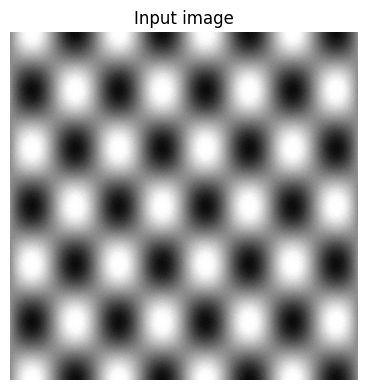

In [5]:
n_blocks = math.ceil(H/TILE) * math.ceil(W/TILE)
ai_tiled = H*W*2*K*K / (n_blocks * SHARED_DIM**2 * 4)
print(f"  Tiled  : {ai_tiled:.3f} FLOP/byte  ({ai_tiled/0.5:.0f}x improvement over naive)")

plt.figure(figsize=(4, 4))
plt.imshow(h_img, cmap='gray', vmin=0, vmax=1)
plt.title('Input image')
plt.axis('off')
plt.tight_layout()
plt.show()

---

## Stage 1 — CPU Baseline

A direct nested-loop implementation in NumPy. This is the reference: every GPU version must produce output that matches this exactly.

> Note: `np.pad` adds zero-padding so boundary pixels are handled cleanly without extra if-statements.

In [6]:
def conv2d_cpu(img, kernel):
    """
    Reference 2D convolution on CPU.
    img    : (H, W) float32
    kernel : (K, K) float32
    returns: (H, W) float32
    """
    H, W = img.shape
    K    = kernel.shape[0]
    half = K // 2
    padded = np.pad(img, half, mode='constant', constant_values=0.0)
    out = np.zeros((H, W), dtype=np.float32)
    for r in range(H):
        for c in range(W):
            out[r, c] = np.sum(padded[r:r+K, c:c+K] * kernel)

    return out


In [7]:
t0 = time.perf_counter()
cpu_ref = conv2d_cpu(h_img, gaussian_15x15)
t1 = time.perf_counter()
cpu_time_ms = (t1 - t0) * 1000
print(f"CPU time : {cpu_time_ms:.1f} ms")
print(f"Output range: [{cpu_ref.min():.4f}, {cpu_ref.max():.4f}]")

CPU time : 6678.0 ms
Output range: [0.0262, 1.0000]


---

## Stage 2 — Naive `@cuda.jit` Kernel

One thread per output pixel. Each thread reads its K x K neighborhood directly from global memory — no cooperation between threads.

### 2D Index Arithmetic

Unlike 1D kernels, here we use a 2D grid of 2D blocks:

```python
row = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
col = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x
```

And the grid is launched as:

```python
threads = (TILE, TILE)            # e.g. (16, 16) = 256 threads per block
blocks  = (ceil(W/TILE), ceil(H/TILE))
kernel[(blocks, threads)](...)   # NOTE: Numba uses (grid, block) order
```

### Boundary Handling

Threads at the image border need to read pixels that do not exist. We use **zero-padding**: if an index is outside the image, treat it as 0.
> **Rerun note:** If you get `CUDA_ERROR_ILLEGAL_ADDRESS`, the GPU context is corrupted from a previous crashed kernel. Go to **Runtime > Restart session**, then run all cells from the top. Each stage cell uploads its own data independently, so individual cells are safe to rerun *if the context is healthy*.


In [8]:
@cuda.jit
def conv2d_naive(img, kernel, out, H, W, K):
    """
    Naive 2D convolution: one thread per output pixel.
    Each thread reads its neighborhood directly from global memory.
    """
    
    row = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    col = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    # TODO: guard against out-of-bounds threads
    if row >= H or col >= W:
        return

    half = K // 2
    val  = 0.0
    for ki in range(K):
        for kj in range(K):
            r = row + ki - half
            c = col + kj - half
            val = val + (img[r, c] * kernel[ki, kj]) if 0 <= r < H and 0 <= c < W else val

    out[row, col] = val


In [9]:
def cuda_time_ms(func, *args, reps=10):
    """Time a GPU function using CUDA events (correct async timing)."""
    func(*args)  # warmup
    cuda.synchronize()
    start = cuda.event()
    end   = cuda.event()

    start.record()
    for _ in range(reps):
        func(*args)
    end.record()
    end.synchronize()

    return cuda.event_elapsed_time(start, end) / reps

In [10]:
d_img_naive  = cuda.to_device(h_img)
d_kern_naive = cuda.to_device(gaussian_15x15)
threads_2d = (TILE, TILE)
blocks_2d  = (math.ceil(W / TILE), math.ceil(H / TILE))

def kernel_naive(d_img, d_kernel):
    d_out = cuda.device_array((H, W), dtype=np.float32)
    conv2d_naive[blocks_2d, threads_2d](d_img, d_kernel, d_out, H, W, K)
    cuda.synchronize()
    return d_out

In [11]:
# TEST
naive_out = kernel_naive(d_img_naive, d_kern_naive).copy_to_host()
assert np.allclose(naive_out, cpu_ref, atol=1e-4), "Naive kernel: mismatch with CPU!"
print("Correctness check passed")

Correctness check passed


In [12]:
# TIME CHECK
naive_time_ms = cuda_time_ms(kernel_naive, d_img_naive, d_kern_naive)
print(f"Naive kernel  : {naive_time_ms:.3f} ms")
print(f"Speedup vs CPU: {cpu_time_ms / naive_time_ms:.1f}x")

Naive kernel  : 12.142 ms
Speedup vs CPU: 550.0x


---

## Stage 3 — Shared Memory Tiling with Halo

### The Problem with the Naive Kernel

In Stage 2, each thread reads K x K values from global memory independently. Neighboring threads read **overlapping regions** — the same pixel is fetched many times from slow global memory.

For a 15x15 filter with a 16x16 tile, each interior pixel is read by up to 225 threads.

### The Fix: Shared Memory Tile + Halo

All threads in a block **cooperate** to load a tile of the image — plus a border of extra pixels (the **halo**) — into fast shared memory. Then every thread reads its neighborhood from shared memory instead of global memory.

```
Shared memory tile layout (TILE=4, K=3, half=1):

  +--+--+--+--+--+--+
  |  halo (top)    |
  +--+--+--+--+--+--+
  |h |            |h|
  |a |   TILE     |a|
  |l |  (output   |l|
  |o |  pixels)   |o|
  +--+--+--+--+--+--+
  |  halo (bottom) |
  +--+--+--+--+--+--+

  Shared tile size = (TILE + 2*half) x (TILE + 2*half)
```

### Loading the Halo

The shared tile is larger than the block (TILE + 2*half in each dimension). Some threads need to load **multiple elements** to fill the halo. We use a loop with stride `blockDim` so every element is covered.

> This is the most important concept in this lab. The halo pattern appears in CNN layers, stencil solvers, and any operation where each output depends on a neighborhood of inputs.

In [13]:
d_img_tiled  = cuda.to_device(h_img)
d_kern_tiled = cuda.to_device(gaussian_15x15)

@cuda.jit
def conv2d_tiled_specialized(img, kernel, out, H, W, K):
    """
    Tiled 2D convolution with shared memory halo.
    Specialized for TILE=16, K=15 (SHARED_DIM = TILE + 2*HALF_K = 30).
    """
    # SHARED_DIM = TILE + 2*HALF_K = 16 + 2*7 = 30  (must be a literal for Numba)
    smem = cuda.shared.array(shape=(30, 30), dtype=numba.float32)
    half = K // 2
    out_row = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    out_col = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    tile_row_start = cuda.blockIdx.y * cuda.blockDim.y - half
    tile_col_start = cuda.blockIdx.x * cuda.blockDim.x - half
    ty = cuda.threadIdx.y
    tx = cuda.threadIdx.x

    loop_sy = ty
    while loop_sy < 30:
        loop_sx = tx
        while loop_sx < 30:
            global_row = tile_row_start + loop_sy
            global_col = tile_col_start + loop_sx
            if 0 <= global_row < H and 0 <= global_col < W:
                smem[loop_sy, loop_sx] = img[global_row, global_col]
            else:
                smem[loop_sy, loop_sx] = 0.0
            loop_sx += cuda.blockDim.x
        loop_sy += cuda.blockDim.y

    cuda.syncthreads()

    if out_row < H and out_col < W:
        val = 0.0
        for ki in range(K):
            for kj in range(K):
                val += smem[ty + ki, tx + kj] * kernel[ki, kj]

        out[out_row, out_col] = val


In [14]:
def kernel_tiled(d_img, d_kernel):
    d_out = cuda.device_array((H, W), dtype=np.float32)
    conv2d_tiled_specialized[blocks_2d, threads_2d](d_img, d_kernel, d_out, H, W, K)
    cuda.synchronize()
    return d_out

In [15]:
# TEST
tiled_out = kernel_tiled(d_img_tiled, d_kern_tiled).copy_to_host()
assert np.allclose(tiled_out, cpu_ref, atol=1e-4), "Tiled kernel: mismatch with CPU!"
print("Correctness check passed")

Correctness check passed


In [16]:
# TIME CHECK
tiled_time_ms = cuda_time_ms(kernel_tiled, d_img_tiled, d_kern_tiled)
print(f"Tiled kernel  : {tiled_time_ms:.3f} ms")
print(f"Speedup vs CPU        : {cpu_time_ms / tiled_time_ms:.1f}x")
print(f"Speedup vs naive GPU  : {naive_time_ms / tiled_time_ms:.2f}x")

Tiled kernel  : 8.816 ms
Speedup vs CPU        : 757.5x
Speedup vs naive GPU  : 1.38x


---

## Stage 4 — Read-Only Device Array for Filter Weights

### Why avoid re-uploading the filter every call?

In Stage 3, the filter is transferred to GPU inside the timed function on every call. For a single image this is negligible, but in a real pipeline (batch inference, video processing) the same filter weights are used thousands of times. Uploading them repeatedly wastes PCIe bandwidth.

The fix: upload once with `cuda.to_device`, keep the device array alive, and reuse it across all calls.

### Why this approximates constant memory

CUDA C has a dedicated `__constant__` memory space (64 KB, separate cache) designed for exactly this pattern: small, read-only data accessed uniformly by all threads. When a warp reads the same address, the hardware serves it as a **single broadcast** rather than 32 separate fetches.

Numba does not expose a Python-side API for `__constant__` memory (`cuda.const.array_like` raises `NotImplementedError` from host code). The correct Numba equivalent is:

1. Upload with `cuda.to_device` once at module level
2. Pass as a read-only argument — the driver caches it in L1 on Volta+ GPUs

On T4/A100/RTX GPUs, the unified L1 cache gives broadcast-read behavior nearly identical to `__constant__` for small arrays like filter weights.

```
Memory hierarchy (fastest to slowest):

  Registers           ~1 cycle
  Shared memory       ~5 cycles
  L1 / const cache    ~5 cycles  <-- filter weights land here
  L2 cache            ~30 cycles
  Global memory       ~200 cycles
```

> In your final project: model weights, physical constants, lookup tables — any small read-only data shared across all threads — should be uploaded once and reused, not transferred per batch.


In [17]:
d_img_const    = cuda.to_device(h_img)
d_kernel_15x15 = cuda.to_device(gaussian_15x15)  # uploaded once, reused
d_kernel_sx    = cuda.to_device(sobel_x)

@cuda.jit
def conv2d_const_mem(img, filt, out, H, W, K):
    """
    Tiled convolution — filter passed as pre-loaded read-only device array.
    Specialized for TILE=16, K=15 (SHARED_DIM=30).
    """
    smem = cuda.shared.array(shape=(30, 30), dtype=numba.float32)
    half = K // 2
    out_row = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    out_col = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x
    tile_row_start = cuda.blockIdx.y * cuda.blockDim.y - half
    tile_col_start = cuda.blockIdx.x * cuda.blockDim.x - half
    ty, tx = cuda.threadIdx.y, cuda.threadIdx.x

    loop_sy = ty
    while loop_sy < 30:
        loop_sx = tx
        while loop_sx < 30:
            global_row = tile_row_start + loop_sy
            global_col = tile_col_start + loop_sx
            if 0 <= global_row < H and 0 <= global_col < W:
                smem[loop_sy, loop_sx] = img[global_row, global_col]
            else:
                smem[loop_sy, loop_sx] = 0.0
            loop_sx += cuda.blockDim.x
        loop_sy += cuda.blockDim.y

    cuda.syncthreads()

    if out_row < H and out_col < W:
        val = 0.0
        for ki in range(K):
            for kj in range(K):
                val += smem[ty + ki, tx + kj] * filt[ki, kj]

        out[out_row, out_col] = val


In [18]:
def kernel_const(d_img, d_filt):
    d_out = cuda.device_array((H, W), dtype=np.float32)
    conv2d_const_mem[blocks_2d, threads_2d](d_img, d_filt, d_out, H, W, K)
    cuda.synchronize()
    return d_out

In [19]:
# TEST
const_out = kernel_const(d_img_const, d_kernel_15x15).copy_to_host()
assert np.allclose(const_out, cpu_ref, atol=1e-4), "Const mem kernel: mismatch!"
print("Correctness check passed")

Correctness check passed


In [20]:
# TIME CHECK
const_time_ms = cuda_time_ms(kernel_const, d_img_const, d_kernel_15x15)
print(f"Read-only filter kernel : {const_time_ms:.3f} ms")
print(f"Speedup vs CPU          : {cpu_time_ms / const_time_ms:.1f}x")
print(f"Speedup vs naive GPU    : {naive_time_ms / const_time_ms:.2f}x")
print(f"Speedup vs tiled GPU    : {tiled_time_ms / const_time_ms:.2f}x")

Read-only filter kernel : 7.530 ms
Speedup vs CPU          : 886.9x
Speedup vs naive GPU    : 1.61x
Speedup vs tiled GPU    : 1.17x


---

## Stage 5 — Thread Coarsening (Multiple Output Pixels per Thread)

### The Problem with One-Thread-One-Pixel

In Stages 3 and 4, each thread loads its share of the shared memory tile and then computes exactly **one** output pixel. The ratio of useful work (one dot product) to setup cost (loading the halo) is fixed.

**Thread coarsening** changes this ratio: each thread computes **multiple output pixels** arranged in a strip, reusing the same loaded tile data for all of them. This is sometimes called "register tiling".

### How it changes arithmetic intensity

With coarsening factor `CY` (each thread handles `CY` rows):
- Shared memory loads: same as before (one tile per block)
- Arithmetic: `CY` times more FLOPs per thread
- Result: arithmetic intensity increases by ~`CY`x

```
Without coarsening (CY=1):         With coarsening (CY=2):

Block (4 threads shown):           Block (4 threads, each does 2 rows):
 T0 -> pixel (0,0)                  T0 -> pixel (0,0) and (1,0)
 T1 -> pixel (0,1)                  T1 -> pixel (0,1) and (1,1)
 T2 -> pixel (1,0)                  T2 -> pixel (2,0) and (3,0)
 T3 -> pixel (1,1)                  T3 -> pixel (2,1) and (3,1)
```

### The tradeoff: occupancy vs reuse

Coarsening reduces the number of threads launched (by factor `CY`). Fewer threads = fewer warps in flight = lower occupancy. There is a sweet spot where the reuse benefit outweighs the occupancy loss. This is a key tuning decision in production GPU kernels.

> This is exactly how cuDNN, TensorRT, and other high-performance libraries achieve utilization close to the roofline — they coarsen threads aggressively to maximize arithmetic intensity.

### Shared memory layout for coarsening

With `CY=2`, each block covers `CY*TILE` output rows, so the shared tile must also grow:
```
SHARED_ROWS = CY * TILE + 2 * half
SHARED_COLS = TILE + 2 * half
```

In [21]:
d_img_coarse  = cuda.to_device(h_img)
d_kern_coarse = cuda.to_device(gaussian_15x15)

CY = 2  # coarsening factor: each thread computes CY output rows
# SHARED_ROWS = CY * TILE + 2 * HALF_K = 2*16 + 2*7 = 46
# SHARED_COLS = TILE + 2 * HALF_K       = 16 + 2*7  = 30
SHARED_ROWS_CY = CY * TILE + 2 * HALF_K  # = 46
SHARED_COLS_CY = TILE + 2 * HALF_K       # = 30

@cuda.jit
def conv2d_coarsened(img, filt, out, H, W, K, CY):
    """
    Thread-coarsened convolution: each thread computes CY output rows.
    Shared memory tile covers CY*TILE output rows + halo on all sides.
    Specialized for TILE=16, K=15, CY=2: SHARED_ROWS=46, SHARED_COLS=30.
    """
    # SHARED_ROWS = CY*TILE + 2*half = 2*16 + 2*7 = 46
    # SHARED_COLS = TILE + 2*half    = 16 + 2*7   = 30
    smem = cuda.shared.array(shape=(46, 30), dtype=numba.float32)

    half = K // 2
    ty, tx = cuda.threadIdx.y, cuda.threadIdx.x

    tile_row_start = cuda.blockIdx.y * (cuda.blockDim.y * CY) - half
    tile_col_start = cuda.blockIdx.x * cuda.blockDim.x - half

    sy = ty
    while sy < SHARED_ROWS_CY:
        sx = tx
        while sx < SHARED_COLS_CY:
            global_row = tile_row_start + sy
            global_col = tile_col_start + sx
            if 0 <= global_row < H and 0 <= global_col < W:
                smem[sy, sx] = img[global_row, global_col]
            else:
                smem[sy, sx] = 0.0
            sx += cuda.blockDim.x
        sy += cuda.blockDim.y

    cuda.syncthreads()

    out_col = cuda.blockIdx.x * cuda.blockDim.x + tx

    for cy in range(CY):
        out_row = cuda.blockIdx.y * (cuda.blockDim.y * CY) + cy * cuda.blockDim.y + ty
        if out_row < H and out_col < W:
            val = 0.0
            smem_row_base = half + cy * cuda.blockDim.y + ty
            smem_col_base = half + tx
            for ki in range(K):
                for kj in range(K):
                    val += smem[smem_row_base - half + ki, smem_col_base - half + kj] * filt[ki, kj]
            out[out_row, out_col] = val


In [22]:
blocks_coarse = (math.ceil(W / TILE), math.ceil(H / (TILE * CY)))

def kernel_coarsened(d_img, d_filt):
    d_out = cuda.device_array((H, W), dtype=np.float32)
    conv2d_coarsened[blocks_coarse, threads_2d](d_img, d_filt, d_out, H, W, K, CY)
    cuda.synchronize()
    return d_out

In [23]:
# TEST
coarse_out = kernel_coarsened(d_img_coarse, d_kern_coarse).copy_to_host()
assert np.allclose(coarse_out, cpu_ref, atol=1e-4), f"Coarsened kernel: mismatch! max diff={abs(coarse_out - cpu_ref).max():.6f}"
print("Correctness check passed")

Correctness check passed


In [24]:
# TIME CHECK
coarse_time_ms = cuda_time_ms(kernel_coarsened, d_img_coarse, d_kern_coarse)
print(f"Tiled          : {tiled_time_ms:.2f} ms")
print(f"Const mem      : {const_time_ms:.2f} ms")
print(f"Coarsened CY={CY} : {coarse_time_ms:.2f} ms")
print()
print(f"Speedup vs CPU        : {cpu_time_ms / coarse_time_ms:.1f}x")
print(f"Speedup vs naive GPU  : {naive_time_ms / coarse_time_ms:.1f}x")
print(f"Speedup vs tiled GPU  : {tiled_time_ms / coarse_time_ms:.1f}x")
print(f"Speedup vs const mem  : {const_time_ms / coarse_time_ms:.1f}x")
print()
print(f"Try changing CY to 4 or 8 and re-run to observe the occupancy tradeoff.")

Tiled          : 8.82 ms
Const mem      : 7.53 ms
Coarsened CY=2 : 12.32 ms

Speedup vs CPU        : 542.0x
Speedup vs naive GPU  : 1.0x
Speedup vs tiled GPU  : 0.7x
Speedup vs const mem  : 0.6x

Try changing CY to 4 or 8 and re-run to observe the occupancy tradeoff.


---

## Stage 6 — Multiple Filters, Same Infrastructure

One of the most important principles in parallel programming is **separating the parallel structure from the computation**. Now that we have a working tiled kernel, we can apply it to completely different filters by only changing the weight matrix — no kernel code changes needed.

### Task 4.1
Apply the tiled kernel to all four filters below and display the results. Verify each output differs from the original image in the expected way (blur softens, Sobel detects edges, sharpen enhances detail).

> Note: Sobel X and Sobel Y are 3x3 filters. You will need to adjust `HALF_K` and `SHARED_DIM` or launch with a separate specialized kernel. Think about how a real framework would handle variable filter sizes.

In [25]:
# Specialized tiled kernel for K=3 (Sobel, Sharpen)
HALF_K3    = 1
SHARED_DIM3 = TILE + 2 * HALF_K3  # = 18

@cuda.jit
def conv2d_tiled_k3(img, kernel, out, H, W, K):
    """Tiled convolution specialized for K=3."""
    # SHARED_DIM3 = TILE + 2*HALF_K3 = 16 + 2*1 = 18
    smem = cuda.shared.array(shape=(18, 18), dtype=numba.float32)
    half = K // 2

    out_row = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    out_col = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    tile_row_start = cuda.blockIdx.y * cuda.blockDim.y - half
    tile_col_start = cuda.blockIdx.x * cuda.blockDim.x - half

    ty, tx = cuda.threadIdx.y, cuda.threadIdx.x
    sy = ty

    while sy < 18:
        sx = tx
        while sx < 18:
            gr = tile_row_start + sy
            gc = tile_col_start + sx
            smem[sy, sx] = img[gr, gc] if (0 <= gr < H and 0 <= gc < W) else 0.0
            sx += cuda.blockDim.x
        sy += cuda.blockDim.y

    cuda.syncthreads()

    if out_row < H and out_col < W:
        val = 0.0
        for ki in range(K):
            for kj in range(K):
                val += smem[ty + ki, tx + kj] * kernel[ki, kj]
        out[out_row, out_col] = val

In [26]:
def run_filter(h_img, h_kernel):
    """Auto-dispatch to the right specialized kernel based on K."""
    H, W = h_img.shape
    K    = h_kernel.shape[0]

    d_img    = cuda.to_device(h_img)
    d_kernel = cuda.to_device(h_kernel)
    d_out    = cuda.device_array((H, W), dtype=np.float32)

    threads  = (TILE, TILE)
    blocks   = (math.ceil(W / TILE), math.ceil(H / TILE))

    if K == 5:
        conv2d_tiled_specialized[blocks, threads](d_img, d_kernel, d_out, H, W, K)
    elif K == 3:
        conv2d_tiled_k3[blocks, threads](d_img, d_kernel, d_out, H, W, K)

    cuda.synchronize()

    return d_out.copy_to_host()

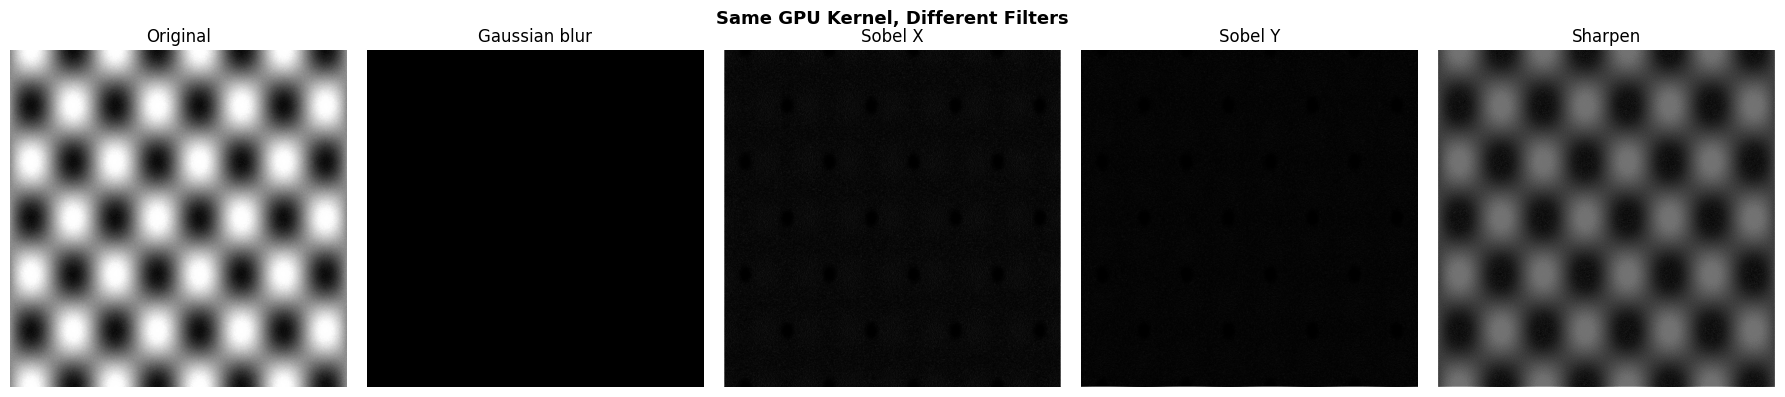

Timing all filters:
  Gaussian 15x15  : 3.70 ms
  Sobel X         : 3.71 ms
  Sobel Y         : 3.75 ms
  Sharpen         : 3.96 ms


In [27]:
# VISUALIZATION
filters = {
    'Original':      h_img,
    'Gaussian blur': run_filter(h_img, gaussian_15x15),
    'Sobel X':       run_filter(h_img, sobel_x),
    'Sobel Y':       run_filter(h_img, sobel_y),
    'Sharpen':       run_filter(h_img, sharpen),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (name, img_out) in zip(axes, filters.items()):
    display = np.abs(img_out)  # abs for Sobel which can go negative
    display = (display - display.min()) / (display.max() - display.min() + 1e-8)
    ax.imshow(display, cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.suptitle('Same GPU Kernel, Different Filters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('filters.png', dpi=120, bbox_inches='tight')
plt.show()

print("Timing all filters:")
for name, h_kernel in [('Gaussian 15x15', gaussian_15x15), ('Sobel X', sobel_x), ('Sobel Y', sobel_y), ('Sharpen', sharpen)]:
    t = cuda_time_ms(run_filter, h_img, h_kernel)
    print(f"  {name:<16}: {t:.2f} ms")

---

## Stage 7 — Roofline Analysis

Now that we have two working GPU implementations, we want to understand *why* one is faster than the other and *how close* we are to the hardware limit.

### Arithmetic Intensity

**Arithmetic intensity (AI)** = FLOPs / bytes of memory traffic.

For 2D convolution with a K x K filter on an H x W image:
- FLOPs per output pixel: `2 * K * K` (K*K multiplies + K*K adds)
- Total FLOPs: `H * W * 2 * K * K`

**Memory traffic:**
- Naive kernel: each of H*W pixels reads K*K floats from global memory → `H * W * K * K * 4` bytes
- Tiled kernel: each tile of `TILE*TILE` pixels loads `(TILE+2*half)^2` floats once → less total traffic

### The Roofline Model

A GPU has two ceilings:
- **Compute ceiling**: peak FLOP/s (TFLOPS)
- **Memory ceiling**: peak bandwidth (GB/s) × arithmetic intensity

A kernel's performance is bounded by whichever ceiling it hits first. Most convolution kernels with small filters are **memory-bandwidth bound** — the shared memory tiling helps by increasing the effective arithmetic intensity.

### Task 5.1
Complete the analysis below. Calculate theoretical AI for both kernels, then compare measured GFLOP/s against the GPU's theoretical peak.

In [28]:
# Query real GPU specs
gpu = cuda.get_current_device()
cc_major, cc_minor = gpu.compute_capability
gpu_name = gpu.name.decode() if isinstance(gpu.name, bytes) else gpu.name

# Use pynvml (available in Colab/most GPU environments) for hardware specs
try:
    import pynvml
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)
    mem_info   = pynvml.nvmlDeviceGetMemoryInfo(handle)
    mem_clock_mhz  = pynvml.nvmlDeviceGetMaxClockInfo(handle, pynvml.NVML_CLOCK_MEM)
    core_clock_mhz = pynvml.nvmlDeviceGetMaxClockInfo(handle, pynvml.NVML_CLOCK_SM)

    # Bus width not directly in pynvml — derive from known GPU families
    bus_width_map = {(7,5):256, (7,0):4096, (8,0):5120, (8,6):384, (8,9):384, (9,0):5120}
    bus_width_bits = bus_width_map.get((cc_major, cc_minor), 256)
    PEAK_BW_GBS = mem_clock_mhz * 1e6 * bus_width_bits / 8 / 1e9 * 2
    pynvml.nvmlShutdown()

except Exception:
    # Fallback: use known T4 values; update if on a different GPU
    mem_clock_mhz  = 5001   # T4 memory clock MHz
    core_clock_mhz = 1590   # T4 boost clock MHz
    bus_width_bits = 256    # T4 bus width
    PEAK_BW_GBS    = 300.0  # T4 ~300 GB/s

sm_count = gpu.MULTIPROCESSOR_COUNT
cores_per_sm = {
    (7, 0): 64,   # V100
    (7, 5): 64,   # T4
    (8, 0): 64,   # A100
    (8, 6): 128,  # RTX 3090
    (8, 9): 128,  # RTX 4090
    (9, 0): 128,  # H100
}.get((cc_major, cc_minor), 64)

PEAK_TFLOPS = sm_count * cores_per_sm * 2 * core_clock_mhz * 1e6 / 1e12

print(f"GPU                  : {gpu_name}")
print(f"Compute capability   : {cc_major}.{cc_minor}")
print(f"SMs                  : {sm_count}")
print(f"FP32 cores/SM        : {cores_per_sm}")
print(f"Core clock           : {core_clock_mhz} MHz")
print(f"Memory clock         : {mem_clock_mhz} MHz")
print(f"Memory bus width     : {bus_width_bits} bits")
print(f"Peak FP32 (computed) : {PEAK_TFLOPS:.2f} TFLOPS")
print(f"Peak bandwidth       : {PEAK_BW_GBS:.1f} GB/s")
print("(Peak FP32 is a theoretical upper bound; real-world performance is lower)")

GPU                  : Tesla T4
Compute capability   : 7.5
SMs                  : 40
FP32 cores/SM        : 64
Core clock           : 1590 MHz
Memory clock         : 5001 MHz
Memory bus width     : 256 bits
Peak FP32 (computed) : 8.14 TFLOPS
Peak bandwidth       : 320.1 GB/s
(Peak FP32 is a theoretical upper bound; real-world performance is lower)


In [29]:
# --- Theoretical analysis ---
total_flops  = H * W * 2 * K * K

# Bytes read from global memory
bytes_naive = H * W * K * K * 4  # every output reads K*K floats independently

# Tiled: each (TILE+2*half)^2 region loaded once per block
n_blocks     = math.ceil(H / TILE) * math.ceil(W / TILE)
bytes_tiled  = n_blocks * SHARED_DIM * SHARED_DIM * 4  # SHARED_DIM=30 for K=15

ai_naive   = total_flops / bytes_naive
ai_tiled   = total_flops / bytes_tiled
# Constant memory: same tile traffic as tiled (image still in shared mem)
ai_const   = ai_tiled
# Coarsened: same tile bytes but CY times more FLOPs per tile
ai_coarse  = ai_tiled * CY

print("Arithmetic Intensity:")
print(f"  Naive     : {ai_naive:.3f} FLOP/byte")
print(f"  Tiled     : {ai_tiled:.3f} FLOP/byte")
print(f"  Const mem : {ai_const:.3f} FLOP/byte  (same tile, filter from const cache)")
print(f"  Coarsened : {ai_coarse:.3f} FLOP/byte  ({CY}x reuse of shared tile)")
print(f"  Tiled->Coarsened improvement: {ai_coarse/ai_tiled:.1f}x")

Arithmetic Intensity:
  Naive     : 0.500 FLOP/byte
  Tiled     : 32.000 FLOP/byte
  Const mem : 32.000 FLOP/byte  (same tile, filter from const cache)
  Coarsened : 64.000 FLOP/byte  (2x reuse of shared tile)
  Tiled->Coarsened improvement: 2.0x


In [30]:
# --- Measured performance ---
gflops_naive  = total_flops / (naive_time_ms  / 1000) / 1e9
gflops_tiled  = total_flops / (tiled_time_ms  / 1000) / 1e9
gflops_const  = total_flops / (const_time_ms  / 1000) / 1e9
gflops_coarse = total_flops / (coarse_time_ms / 1000) / 1e9

print(f"\nMeasured GFLOP/s:")
print(f"  Naive     : {gflops_naive:.1f} GFLOP/s  ({gflops_naive/PEAK_TFLOPS/10:.1f}% of peak)")
print(f"  Tiled     : {gflops_tiled:.1f} GFLOP/s  ({gflops_tiled/PEAK_TFLOPS/10:.1f}% of peak)")
print(f"  Const mem : {gflops_const:.1f} GFLOP/s  ({gflops_const/PEAK_TFLOPS/10:.1f}% of peak)")
print(f"  Coarsened : {gflops_coarse:.1f} GFLOP/s  ({gflops_coarse/PEAK_TFLOPS/10:.1f}% of peak)")


Measured GFLOP/s:
  Naive     : 38.9 GFLOP/s  (0.5% of peak)
  Tiled     : 53.5 GFLOP/s  (0.7% of peak)
  Const mem : 62.7 GFLOP/s  (0.8% of peak)
  Coarsened : 38.3 GFLOP/s  (0.5% of peak)


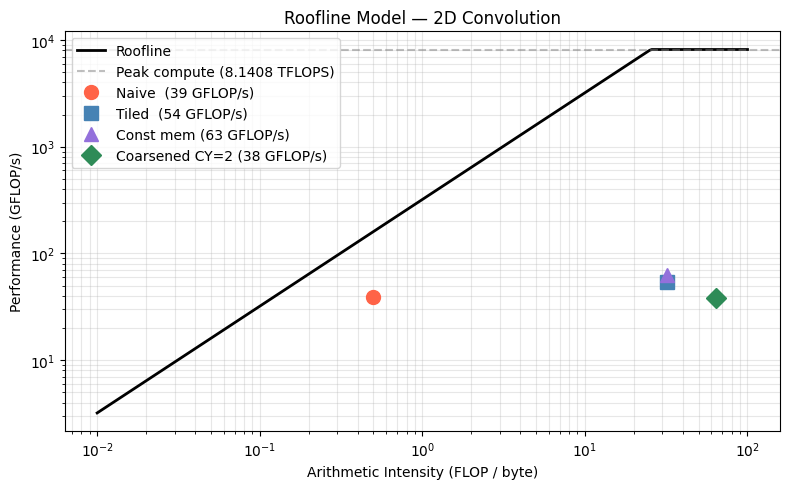

In [31]:
# --- Roofline plot ---
ai_range = np.logspace(-2, 2, 300)
roof_compute  = np.full_like(ai_range, PEAK_TFLOPS * 1000)        # GFLOP/s
roof_memory   = ai_range * PEAK_BW_GBS                             # GFLOP/s
roofline      = np.minimum(roof_compute, roof_memory)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ai_range, roofline, 'k-', linewidth=2, label='Roofline')
ax.axhline(PEAK_TFLOPS * 1000, color='gray', linestyle='--', alpha=0.5, label=f'Peak compute ({PEAK_TFLOPS} TFLOPS)')
ax.loglog(ai_naive,  gflops_naive,  'o', color='tomato',    markersize=10, label=f'Naive  ({gflops_naive:.0f} GFLOP/s)')
ax.loglog(ai_tiled,  gflops_tiled,  's', color='steelblue', markersize=10, label=f'Tiled  ({gflops_tiled:.0f} GFLOP/s)')
ax.loglog(ai_const,  gflops_const,  '^', color='mediumpurple', markersize=10, label=f'Const mem ({gflops_const:.0f} GFLOP/s)')
ax.loglog(ai_coarse, gflops_coarse, 'D', color='seagreen',  markersize=10, label=f'Coarsened CY={CY} ({gflops_coarse:.0f} GFLOP/s)')
ax.set_xlabel('Arithmetic Intensity (FLOP / byte)')
ax.set_ylabel('Performance (GFLOP/s)')
ax.set_title('Roofline Model — 2D Convolution')
ax.legend()

ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('roofline.png', dpi=120, bbox_inches='tight')
plt.show()

In [32]:
ridge = PEAK_TFLOPS * 1000 / PEAK_BW_GBS
print(f"  Ridge point (memory/compute boundary): {ridge:.2f} FLOP/byte")
print(f"  All kernels have AI << {ridge:.1f} -> memory-bandwidth bound")
print(f"  Coarsening increases AI by {CY}x, moving the kernel rightward on the roofline.")
print(f"  The goal is to reach the ridge point; beyond it, we become compute-bound.")

  Ridge point (memory/compute boundary): 25.43 FLOP/byte
  All kernels have AI << 25.4 -> memory-bandwidth bound
  Coarsening increases AI by 2x, moving the kernel rightward on the roofline.
  The goal is to reach the ridge point; beyond it, we become compute-bound.


---

## Stage 8 — Summary & Speedup Chart

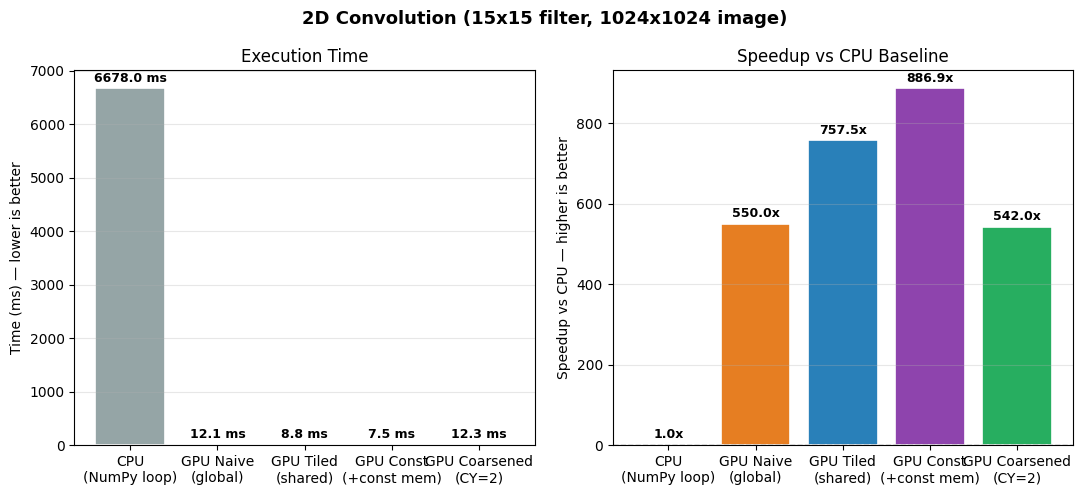

Method                     Time (ms)    Speedup
-----------------------------------------------
CPU (NumPy loop)             6678.04       1.0x
GPU Naive (global)             12.14     550.0x
GPU Tiled (shared)              8.82     757.5x
GPU Const (+const mem)          7.53     886.9x
GPU Coarsened (CY=2)           12.32     542.0x


In [33]:
timings = {
    'CPU\n(NumPy loop)':      cpu_time_ms,
    'GPU Naive\n(global)':    naive_time_ms,
    'GPU Tiled\n(shared)':    tiled_time_ms,
    'GPU Const\n(+const mem)': const_time_ms,
    f'GPU Coarsened\n(CY={CY})': coarse_time_ms,
}

labels   = list(timings.keys())
times    = list(timings.values())
speedups = [cpu_time_ms / t for t in times]
colors   = ['#95a5a6', '#e67e22', '#2980b9', '#8e44ad', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

bars = axes[0].bar(labels, times, color=colors, edgecolor='white', linewidth=1.2)
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
                 f'{t:.1f} ms', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Time (ms) — lower is better')
axes[0].set_title('Execution Time')
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(labels, speedups, color=colors, edgecolor='white', linewidth=1.2)
for bar, s in zip(bars2, speedups):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(speedups)*0.01,
                 f'{s:.1f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(y=1, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel('Speedup vs CPU — higher is better')
axes[1].set_title('Speedup vs CPU Baseline')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'2D Convolution ({K}x{K} filter, {H}x{W} image)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('speedup_chart.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"{'Method':<25} {'Time (ms)':>10} {'Speedup':>10}")
print('-' * 47)
for label, t, s in zip(labels, times, speedups):
    print(f"{label.replace(chr(10), ' '):<25} {t:>10.2f} {s:>9.1f}x")

---

## Reflection Questions

Answer these in the cell below (2–4 sentences each):

1. **Halo loading:** Why do threads need to load more elements than just their own output pixel? What would happen if you forgot to load the halo?

2. **`cuda.syncthreads()`:** Why is it required after loading shared memory, but not inside the convolution computation loop?

3. **Roofline:** Based on your Stage 7 results, are all kernels memory-bandwidth bound or compute bound? What would need to change to push into the compute-bound regime?

4. **Thread coarsening tradeoff:** What happens to performance when CY is too large? Why? What GPU hardware concept explains this?

5. **Connection to final project:** Identify one operation in your chosen final project that follows the same neighborhood-access pattern as 2D convolution. How would you apply shared memory tiling to accelerate it?


**1. Halo loading:** Each thread only makes 1 output pixel, but to make that pixel it needs the K×K box around it, and K=15 here so HALF_K=7. That means it needs 7 more pixels on every side, not just its own pixel. So if the block only loads the 16×16 pixels that match its own threads, the threads near the edge of the tile won't have those extra 7 pixels and will end up reading empty/garbage `smem` values. Then the output near every tile edge would be wrong, and since this happens at every tile in the whole image, we'd get a repeating pattern of wrong pixels, not just one mistake in one place.

**2. `cuda.syncthreads()`:** We need it right after loading `smem` because not all 256 threads finish loading at the same speed — some are faster, some are slower. If we don't wait, a fast thread could start reading `smem` to do its convolution sum before a slow thread even finished writing its part, so we'd get wrong numbers (this is called a race condition, I think). But in the loop that computes the sum, every thread is just reading from `smem` (already fully loaded by that point) and writing to its own `val` variable, so no thread is waiting on another thread anymore — that's probably why we don't need to sync again there, it would just waste time.

**3. Roofline:** In Stage 7 the ridge point is 25.43 FLOP/byte. Tiled/Const have AI = 32 and Coarsened has AI = 64, so on paper they already pass the ridge point. But the actual measured speed is still really low: Naive 38.9, Tiled 53.5, Const 62.7, Coarsened 38.3 GFLOP/s, and all of those are under 1% of the 8.14 TFLOPS peak. So I think all 4 kernels are still memory-bandwidth bound, we're not close to either the compute ceiling or the 320 GB/s bandwidth ceiling. It looks like something else (maybe the image just isn't big enough, or too much overhead from launching lots of small blocks) is slowing things down before we even reach the roofline. To actually become compute bound we'd probably need a much bigger filter K or somehow give each kernel launch a lot more real work to do.

**4. Thread coarsening tradeoff:** After I fixed the missing `syncthreads()` and reran, CY=2 turned out to be the slowest GPU kernel of all — 12.32ms, even slower than Naive (12.14ms), and way slower than Tiled (8.82ms) and Const (7.53ms). My guess is each thread now needs more registers to hold `CY` sums at once, and the shared memory tile is also bigger (46 rows instead of 30), so each block eats up more resources on the SM. That means fewer blocks can be resident on the same SM at the same time. I think the hardware concept here is occupancy — fewer blocks/warps running together means when one warp is stuck waiting for memory, there's no other warp ready to take over, so the SM sits idle more, even though we technically did more math per memory load.

**5. Connection to final project (NMS):** My final project is Non-Max Suppression (NMS) for object detection. I think the IoU part is kind of like convolution's neighborhood pattern — instead of a pixel needing its K×K neighbor pixels, each box needs to be compared against a bunch of other boxes to get its IoU score. And just like nearby threads in convolution keep re-reading the same overlapping pixels, a lot of IoU comparisons would keep re-reading the same box coordinates over and over. So I'd try to do the same shared memory trick: load a group of box coordinates into `smem` once per block, then let every thread in that block reuse them from shared memory instead of going back to global memory every time it needs to compare against a box.
